In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("placement.csv")

In [36]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [37]:
df.shape

(1000, 3)

In [38]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

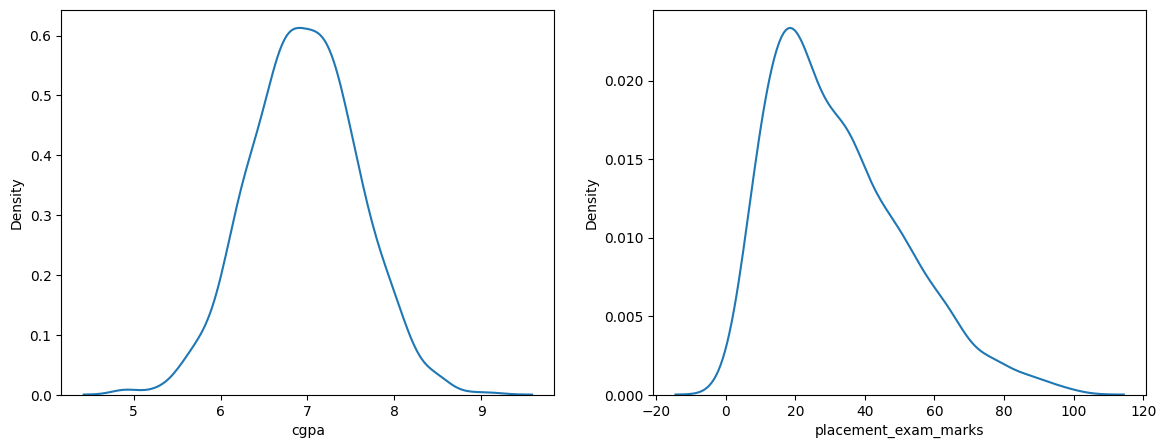

In [39]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.kdeplot(df["cgpa"])

plt.subplot(1,2,2)
sns.kdeplot(df["placement_exam_marks"])


In [13]:
mean_cgpa = df['cgpa'].mean()
std_cgpa = df['cgpa'].std()

In [19]:
upper_limit = mean_cgpa + 3* std_cgpa
lower_limit = mean_cgpa  -3* std_cgpa
lower_limit

np.float64(5.113546374602832)

In [21]:
#trimming
new_df =  df[(df['cgpa'] < upper_limit) & (df['cgpa'] > lower_limit)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [29]:
new_df["cgpa"].mean() + 3* new_df["cgpa"].std()

np.float64(8.763601707753606)

#capping


In [30]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [40]:
df['cgpa']= np.where(df['cgpa']> upper_limit, upper_limit,
            np.where(df['cgpa']< lower_limit,
                    lower_limit,
                    df['cgpa']))

In [60]:
df['placed'].unique()

array([1, 0])

In [42]:
from scipy import stats

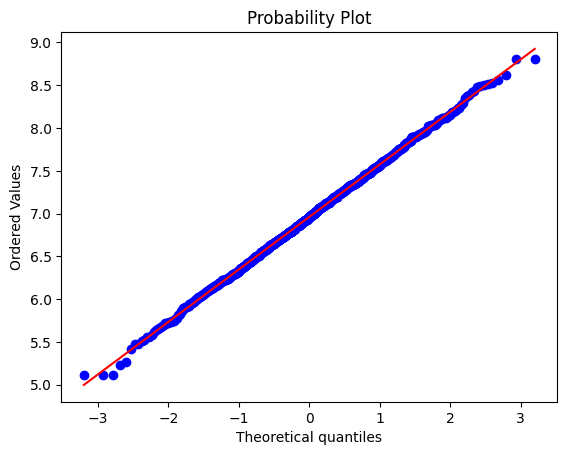

In [48]:
stats.probplot(df['cgpa'],dist="norm",plot=plt)
plt.show()

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score

In [56]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("placed",axis=1),
                                                  df["placed"],
                                                  test_size=0.3,
                                                  random_state=42)

In [68]:
y_train.value_counts()

placed
0    354
1    346
Name: count, dtype: int64

In [57]:
li= LinearRegression()
li.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = li.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

ValueError: Classification metrics can't handle a mix of binary and continuous targets